# Compare savegames — abstract food market

Loads format-2 `.pkl` files and uses the **`market_food`** table only (engine abstract food market: stockpile `food`, `food_max`, `price`, flows — **not** per-good rows in `market_goods`).

Each payload must include a **non-empty** `market_food` DataFrame (`market_goods` is not required).

**Single snapshot:** set `last_savegame = 1` and `first_savegame = 0`, or point `PKL_PATH` at a folder with one `.pkl`.

In [11]:
"""Load .pkl snapshots; require non-empty market_food per file."""
import pandas as pd
from IPython.display import display

from analysis.savegame import resolve_pkl_dir, select_market_food_core

# None = auto (newest playthrough under save_game_temp), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0
last_savegame = None  # None = all; use 1 with first_savegame=0 for a single snapshot

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

market_food_by_label: dict[str, pd.DataFrame] = {}
for label, payload in raw.items():
    if not isinstance(payload, dict):
        raise TypeError(f"{label}: expected dict payload, got {type(payload).__name__}")
    mf = payload.get("market_food")
    if not isinstance(mf, pd.DataFrame) or mf.empty:
        raise TypeError(
            f"{label}: expected non-empty market_food DataFrame. "
            "Re-run datalocations / savegame processor with current ProsperPerishCalcs."
        )
    market_food_by_label[label] = mf.copy()
    market_food_by_label[label]["snapshot"] = label

n_snap = len(market_food_by_label)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(market_food_by_label.keys())}")

Loaded 56 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\5f0b39de_c5da_4afa_ba3e_c6fc282a7fc5
Labels: ['20260322_202007', '20260322_202130', '20260322_202250', '20260322_202408', '20260322_202528', '20260322_202653', '20260322_202815', '20260322_202937', '20260322_203103', '20260322_203225', '20260322_203345', '20260322_203509', '20260322_203635', '20260322_203759', '20260322_203929', '20260322_204056', '20260322_204218', '20260322_204344', '20260322_204509', '20260322_204632', '20260322_204754', '20260322_204912', '20260322_205028', '20260322_205146', '20260322_205302', '20260322_205419', '20260322_205535', '20260322_205654', '20260322_205813', '20260322_205931', '20260322_210048', '20260322_210205', '20260322_210328', '20260322_210459', '20260322_210621', '20260322_210738', '20260322_210857', '20260322_211017', '20260322_211141', '20260322_211307', '20260322_211434', '20260322_211601', '20260322_211726', '20260322_211846', '20260322_2120

In [12]:
market_food_all = (
    pd.concat(market_food_by_label.values(), ignore_index=True)
    if market_food_by_label
    else pd.DataFrame()
)

print(
    f"market_food rows: {len(market_food_all)}, columns: {len(market_food_all.columns)} "
    f"(many are flattened impacts_* etc.)"
)

market_food rows: 8000, columns: 833 (many are flattened impacts_* etc.)


In [13]:
# Core engine scalars only (no impacts_* wide columns)
core = select_market_food_core(market_food_all)
display(core.head(20))

,snapshot,market_id,market_center_slug,food,food_max,price,food_consumption,food_supply,food_not_traded,missing,population,capacity
0,20260322_202007,0,lubeck,59123.81803,59123.81803,0.04412,-3569.65822,1739.08969,1739.09022,221.82821,3092.52215,64.22777
1,20260322_202007,1,riga,38479.48309,38479.48309,0.03058,-1765.30166,1835.61149,1835.61149,56.45094,1328.18197,23.18044
2,20260322_202007,2,venice,72234.50826,72234.50826,0.03957,-4348.28336,864.64968,864.64968,318.76127,3555.27550,40.20527
3,20260322_202007,3,novgorod,27108.93171,27108.93171,0.02701,-1259.89737,2839.04627,2839.04627,44.21107,750.80828,11.92666
4,20260322_202007,4,genoa,88446.51387,90480.73238,0.04409,-6563.96882,573.88198,573.88198,956.68724,4574.12603,50.47785
5,20260322_202007,5,london,35541.34719,42781.09812,0.06027,-4566.45207,-597.09636,-597.09625,1010.49098,3083.30337,17.25405
6,20260322_202007,6,dublin,22761.03631,22761.03631,0.02959,-1051.20881,1840.25797,1840.25797,6.60110,943.63526,8.03420
7,20260322_202007,7,edinburgh,20719.42313,21152.43552,0.02596,-764.18740,538.25189,538.25189,70.90823,740.26911,5.15298
8,20260322_202007,8,bruges,0.00558,61257.03734,0.27955,-1768.58097,-0.02287,-0.02406,20.73317,1629.37398,28.70849
9,20260322_202007,9,dubrovnik,25360.30500,25360.30500,0.03885,-1454.29854,741.29896,741.29897,12.95745,1186.61574,12.86019


## Derived: stockpile vs capacity

`food_fill` is `food / food_max` when `food_max > 0` (else NaN).

In [14]:
derived = core.copy()
if "food" in derived.columns and "food_max" in derived.columns:
    fm = derived["food_max"].replace(0, pd.NA)
    derived["food_fill"] = derived["food"] / fm
else:
    derived["food_fill"] = pd.NA

display(derived.sort_values(["snapshot", "market_id"]).head(20))

,snapshot,market_id,market_center_slug,food,food_max,price,food_consumption,food_supply,food_not_traded,missing,population,capacity,food_fill
0,20260322_202007,0,lubeck,59123.81803,59123.81803,0.04412,-3569.65822,1739.08969,1739.09022,221.82821,3092.52215,64.22777,1.000000e+00
1,20260322_202007,1,riga,38479.48309,38479.48309,0.03058,-1765.30166,1835.61149,1835.61149,56.45094,1328.18197,23.18044,1.000000e+00
2,20260322_202007,2,venice,72234.50826,72234.50826,0.03957,-4348.28336,864.64968,864.64968,318.76127,3555.27550,40.20527,1.000000e+00
3,20260322_202007,3,novgorod,27108.93171,27108.93171,0.02701,-1259.89737,2839.04627,2839.04627,44.21107,750.80828,11.92666,1.000000e+00
4,20260322_202007,4,genoa,88446.51387,90480.73238,0.04409,-6563.96882,573.88198,573.88198,956.68724,4574.12603,50.47785,9.775177e-01
5,20260322_202007,5,london,35541.34719,42781.09812,0.06027,-4566.45207,-597.09636,-597.09625,1010.49098,3083.30337,17.25405,8.307722e-01
6,20260322_202007,6,dublin,22761.03631,22761.03631,0.02959,-1051.20881,1840.25797,1840.25797,6.60110,943.63526,8.03420,1.000000e+00
7,20260322_202007,7,edinburgh,20719.42313,21152.43552,0.02596,-764.18740,538.25189,538.25189,70.90823,740.26911,5.15298,9.795290e-01
8,20260322_202007,8,bruges,0.00558,61257.03734,0.27955,-1768.58097,-0.02287,-0.02406,20.73317,1629.37398,28.70849,9.109157e-08
9,20260322_202007,9,dubrovnik,25360.30500,25360.30500,0.03885,-1454.29854,741.29896,741.29897,12.95745,1186.61574,12.86019,1.000000e+00


## Cross-snapshot comparison (two labels)

Set `SNAP_A` and `SNAP_B` to pkl stems, or leave `None` to use first and last chronological label.

In [15]:
labels = list(market_food_by_label.keys())
SNAP_A = None  # e.g. "20260322_150433"
SNAP_B = None

if SNAP_A is None and labels:
    SNAP_A = labels[0]
if SNAP_B is None and len(labels) > 1:
    SNAP_B = labels[-1]
elif SNAP_B is None and len(labels) == 1:
    SNAP_B = labels[0]

if SNAP_A is None or SNAP_B is None:
    print("Not enough snapshots for A/B comparison.")
else:

    def _rename_except_id(df: pd.DataFrame, snap: str) -> pd.DataFrame:
        out = df.drop(columns=["snapshot"], errors="ignore").copy()
        return out.rename(
            columns={c: f"{c}_{snap}" for c in out.columns if c != "market_id"}
        )

    a = _rename_except_id(market_food_by_label[SNAP_A], SNAP_A).set_index("market_id")
    b = _rename_except_id(market_food_by_label[SNAP_B], SNAP_B).set_index("market_id")
    comp = a.join(b, how="outer")

    if f"food_{SNAP_A}" in comp.columns and f"food_{SNAP_B}" in comp.columns:
        comp["delta_food"] = comp[f"food_{SNAP_B}"] - comp[f"food_{SNAP_A}"]
    if f"price_{SNAP_A}" in comp.columns and f"price_{SNAP_B}" in comp.columns:
        comp["delta_price"] = comp[f"price_{SNAP_B}"] - comp[f"price_{SNAP_A}"]
    if f"food_{SNAP_A}" in comp.columns and f"food_max_{SNAP_A}" in comp.columns:
        comp[f"food_fill_{SNAP_A}"] = comp[f"food_{SNAP_A}"] / comp[
            f"food_max_{SNAP_A}"
        ].replace(0, pd.NA)
    if f"food_{SNAP_B}" in comp.columns and f"food_max_{SNAP_B}" in comp.columns:
        comp[f"food_fill_{SNAP_B}"] = comp[f"food_{SNAP_B}"] / comp[
            f"food_max_{SNAP_B}"
        ].replace(0, pd.NA)
    if f"food_fill_{SNAP_A}" in comp.columns and f"food_fill_{SNAP_B}" in comp.columns:
        comp["delta_food_fill"] = (
            comp[f"food_fill_{SNAP_B}"] - comp[f"food_fill_{SNAP_A}"]
        )

    comp = comp.reset_index()
    if "delta_price" in comp.columns:
        show = comp.loc[comp["delta_price"].abs().sort_values(ascending=False).index]
    else:
        show = comp
    print(f"Comparing {SNAP_A} vs {SNAP_B}")
    display(show.head(40))

Comparing 20260322_202007 vs 20260322_213520


,market_id,center_20260322_202007,color_20260322_202007,food_20260322_202007,food_consumption_20260322_202007,food_supply_20260322_202007,food_not_traded_20260322_202007,trade_20260322_202007,missing_20260322_202007,price_20260322_202007,...,impacts_hot_chocolate_20260322_213520,impacts_popularization_of_tobacco_20260322_213520,impacts_eng_growing_addiction_20260322_213520,impacts_ven_coffeehouses_banned_20260322_213520,impacts_pp_cookery_chocolate_20260322_213520,delta_food,delta_price,food_fill_20260322_202007,food_fill_20260322_213520,delta_food_fill
111,111,15637.0,rgb,5203.82033,-137.27647,614.20226,614.20226,NaN,24.57619,0.01776,...,NaN,NaN,NaN,NaN,NaN,-5203.69388,0.54704,1.000000e+00,2.494821e-06,-0.999998
21,21,1503.0,rgb,58579.92005,-4906.32570,97.49113,97.49113,NaN,524.58474,0.05652,...,NaN,NaN,NaN,NaN,NaN,-53596.47193,0.32642,8.560500e-01,1.522283e-02,-0.840827
124,124,14577.0,rgb,629.23622,-10.24897,51.74628,51.74628,NaN,NaN,0.01801,...,NaN,NaN,NaN,NaN,NaN,-172.90625,0.32045,1.000000e+00,5.744859e-02,-0.942551
73,73,11152.0,rgb,56962.79093,-788.63071,3275.22682,3275.22682,NaN,124.83693,0.01540,...,NaN,NaN,NaN,NaN,NaN,-56962.20529,0.27900,1.000000e+00,7.465366e-07,-0.999999
118,118,20802.0,rgb,2751.70155,-69.03739,442.18243,442.18243,NaN,NaN,0.01820,...,NaN,NaN,NaN,NaN,NaN,-329.93112,0.27756,1.000000e+00,1.476401e-01,-0.852360
64,64,10301.0,rgb,0.02319,-6009.71119,-4058.69507,-4058.69500,-0.00007,423.25555,0.28400,...,NaN,NaN,NaN,NaN,NaN,168420.60526,-0.25569,3.006271e-07,1.000000e+00,1.000000
76,76,11716.0,rgb,0.10860,-6297.10380,-2380.18335,-2380.18335,NaN,1655.27515,0.30648,...,NaN,NaN,NaN,NaN,NaN,29996.96533,-0.25453,2.300649e-06,1.000000e+00,0.999998
70,70,10396.0,rgb,0.08592,-10275.82535,-6560.88880,-6560.88880,NaN,385.40085,0.31599,...,NaN,NaN,NaN,NaN,NaN,73333.28365,-0.25024,6.747740e-07,4.887334e-01,0.488733
113,113,14722.0,rgb,10188.82232,-629.18024,425.24549,425.24549,NaN,NaN,0.05760,...,NaN,NaN,NaN,NaN,NaN,-5947.19906,0.24908,6.931000e-01,9.661126e-02,-0.596489
81,81,11321.0,rgb,12521.65571,-630.48338,465.08851,465.08851,NaN,24.85760,0.03248,...,NaN,NaN,NaN,NaN,NaN,-12521.64443,0.24355,1.000000e+00,1.633123e-07,-1.000000


## Column discovery

Full `market_food` rows include many `impacts_*` columns from nested save data. List counts and non-impact names to spot new engine fields.

In [16]:
cols = list(market_food_all.columns)
impacts = [c for c in cols if c.startswith("impacts_") or c.startswith("impact_")]
other = [c for c in cols if c not in impacts]
print(f"Total columns: {len(cols)}")
print(f"impacts_* / impact_* : {len(impacts)}")
print(f"Other columns: {len(other)}")
print("\nNon-impact columns (sorted):")
print(sorted(other))

Total columns: 833
impacts_* / impact_* : 798
Other columns: 35

Non-impact columns (sorted):
['average_migration_attraction', 'capacity', 'center', 'color', 'dialect', 'food', 'food_consumption', 'food_max', 'food_not_traded', 'food_supply', 'language', 'market', 'market_center_slug', 'market_id', 'members', 'merchant', 'merchant_add', 'merchant_capacity', 'merchant_country', 'merchant_original_capacity', 'merchant_original_power', 'merchant_power', 'merchant_temporary_key', 'merchant_temporary_months', 'merchant_temporary_power', 'merchant_used', 'migration', 'missing', 'population', 'price', 'snapshot', 'temporary_months', 'temporary_scale_with_pop', 'temporary_type', 'trade']


## Plots

**Ranked bar chart** — pick one snapshot and show the top *N* markets by a chosen column (`food` stockpile, `food_max`, `price`, `population`, `food_fill`, …). Use `LARGEST = True` for highest/largest and `False` for lowest/smallest (e.g. lowest price).

**Multi-snapshot lines** — follow the markets with the largest average `LINE_RANK_BY` across snapshots, then plot `LINE_METRIC` over time. The x-axis is **game years** like `compare_savegames.ipynb`: first snapshot = `start_year` (1337), then +`years_per_snapshot` (5) per pkl. Wide figure, markers, grid — same as `compare_savegames_market.ipynb`.

Figure sizes follow `compare_savegames_market.ipynb` (`figsize` ≈ `(13 * 1.1, 3.5 * 1.5)` for single panels).

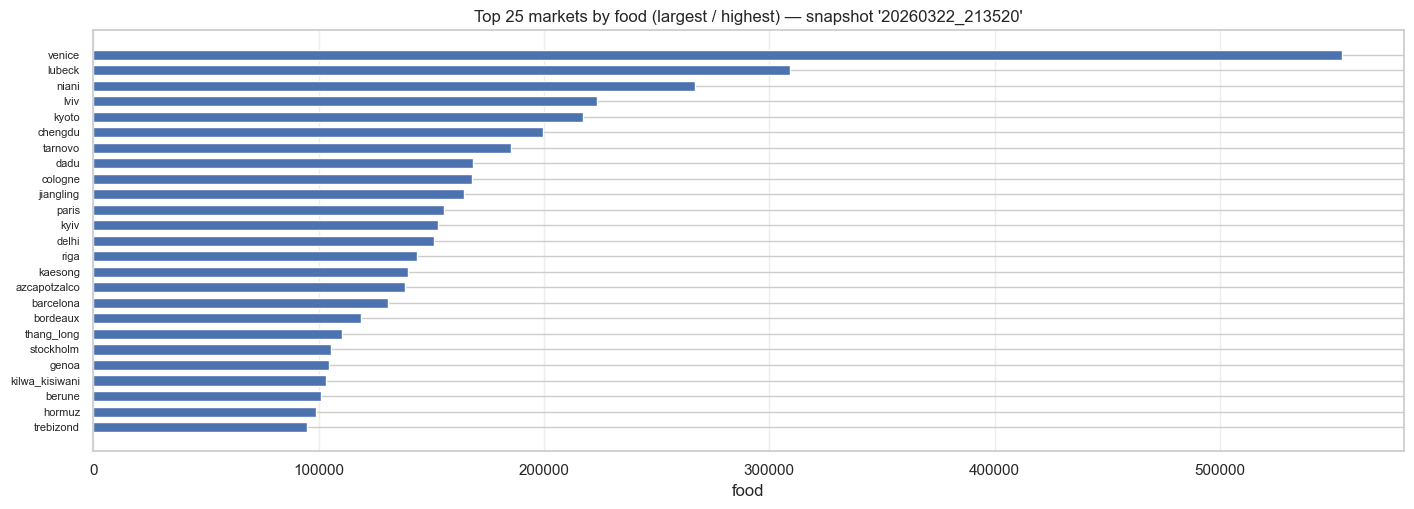

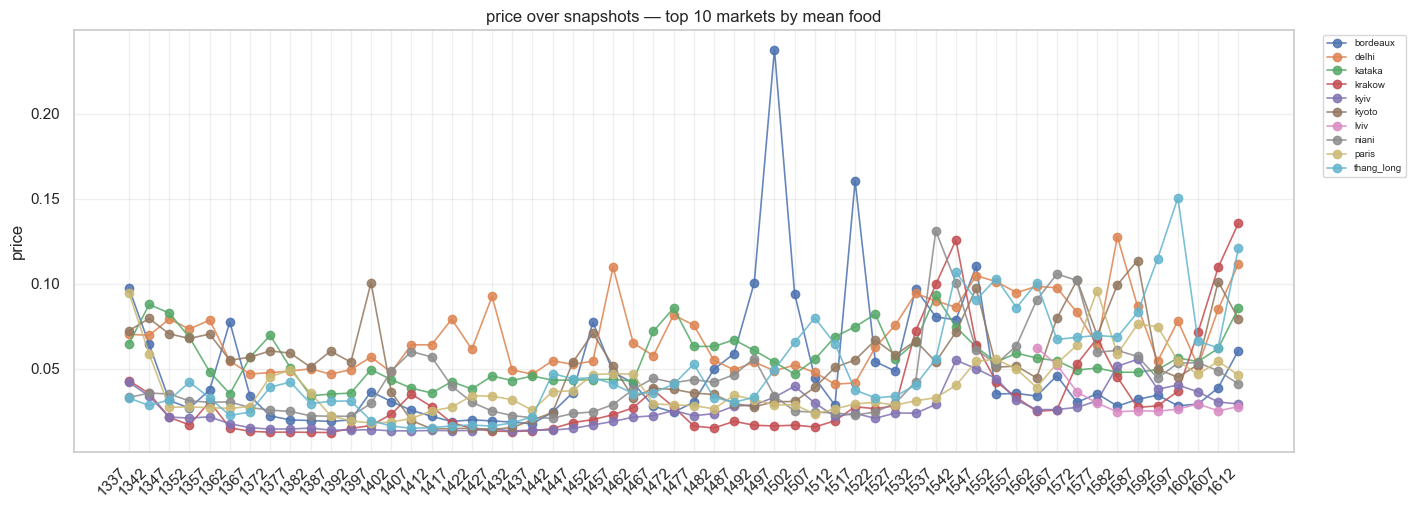

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- Ranked horizontal bar chart (one snapshot) ---
SNAPSHOT_FOR_BARS = None  # None = last loaded snapshot; or e.g. "20260322_152101"
RANK_BY = "food"  # food | food_max | price | population | capacity | food_fill
TOP_N = 25
LARGEST = True  # False -> smallest food / lowest price / ...

# --- Lines across snapshots (markets selected by average rank metric) ---
LINE_METRIC = "price"  # food | price | food_fill | food_max | population | capacity
LINE_TOP_N = 10
LINE_RANK_BY = "food"  # which markets to follow: mean of this column across snapshots

# Same timeline as compare_savegames.ipynb / compare_savegames_market.ipynb
start_year = 1337  # EU5 start
years_per_snapshot = 5

# ---------------------------------------------------------------------------

def _snapshot_key() -> str:
    keys = list(market_food_by_label.keys())
    if not keys:
        raise RuntimeError("No snapshots loaded")
    if SNAPSHOT_FOR_BARS is not None:
        if SNAPSHOT_FOR_BARS not in market_food_by_label:
            raise ValueError(
                f"SNAPSHOT_FOR_BARS={SNAPSHOT_FOR_BARS!r} not in {keys}"
            )
        return SNAPSHOT_FOR_BARS
    return keys[-1]


snap = _snapshot_key()
bar_df = select_market_food_core(market_food_by_label[snap]).copy()
if {"food", "food_max"}.issubset(bar_df.columns):
    bar_df["food_fill"] = bar_df["food"] / bar_df["food_max"].replace(0, pd.NA)

if RANK_BY not in bar_df.columns:
    raise ValueError(
        f"RANK_BY={RANK_BY!r} missing. Columns include: {sorted(bar_df.columns)}"
    )

bar_df = bar_df.dropna(subset=[RANK_BY])
bar_df = bar_df.sort_values(RANK_BY, ascending=not LARGEST).head(int(TOP_N))
bar_df = bar_df.iloc[::-1]

label_col = "market_center_slug" if "market_center_slug" in bar_df.columns else "market_id"
y = np.arange(len(bar_df))
h = max(3.5 * 1.5, 0.2 * len(bar_df))
fig, ax = plt.subplots(figsize=(13 * 1.1, h))
ax.barh(y, bar_df[RANK_BY].values, height=0.65)
ax.set_yticks(y)
ax.set_yticklabels(bar_df[label_col].astype(str), fontsize=8)
ax.set_xlabel(RANK_BY)
order_word = "largest / highest" if LARGEST else "smallest / lowest"
ax.set_title(
    f"Top {len(bar_df)} markets by {RANK_BY} ({order_word}) — snapshot {snap!r}"
)
ax.grid(True, axis="x", alpha=0.35)
plt.tight_layout()
plt.show()

# --- Lines: same top markets over snapshots ---
core_all = select_market_food_core(market_food_all).copy()
if {"food", "food_max"}.issubset(core_all.columns):
    core_all["food_fill"] = core_all["food"] / core_all["food_max"].replace(0, pd.NA)

if LINE_RANK_BY not in core_all.columns or LINE_METRIC not in core_all.columns:
    print(
        "Skip line chart: need LINE_RANK_BY and LINE_METRIC in core table:",
        sorted(core_all.columns),
    )
elif core_all["snapshot"].nunique() < 2:
    print("Skip line chart: need at least 2 snapshots (set last_savegame > 1 or load more pkls).")
else:
    mean_rank = core_all.groupby("market_id")[LINE_RANK_BY].mean().sort_values(
        ascending=False
    )
    top_ids = mean_rank.head(int(LINE_TOP_N)).index
    sub = core_all[core_all["market_id"].isin(top_ids)].copy()
    lab = "market_center_slug" if "market_center_slug" in sub.columns else "market_id"
    piv = sub.pivot_table(
        index="snapshot",
        columns=lab,
        values=LINE_METRIC,
        aggfunc="mean",
    )
    snap_order = sorted(piv.index.tolist(), key=str)
    piv = piv.reindex(snap_order)
    x = np.arange(len(snap_order))

    fig, ax = plt.subplots(figsize=(13 * 1.1, 3.5 * 1.5))
    for col in piv.columns:
        ax.plot(x, piv[col].values, marker="o", label=str(col), alpha=0.85, linewidth=1.2)
    ax.set_xticks(x)
    x_labels = [str(start_year + i * years_per_snapshot) for i in range(len(snap_order))]
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_ylabel(LINE_METRIC)
    ax.set_title(
        f"{LINE_METRIC} over snapshots — top {LINE_TOP_N} markets by mean {LINE_RANK_BY}"
    )
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=1)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Global abstract food market (like goods in `compare_savegames_market`)

**Price** — Distribution of abstract **food price** across all trade markets each snapshot: 10th–90th and 25th–75th percentile bands (across markets), plus the **mean** line (same pattern as the per-good global price panel).

**Supply / demand** — **Sum** of `food_supply` and **−sum** of `food_consumption` (engine consumption is typically negative) as global demand, plus **net** (supply − demand). Same **game year** x-axis as the other compare notebooks.

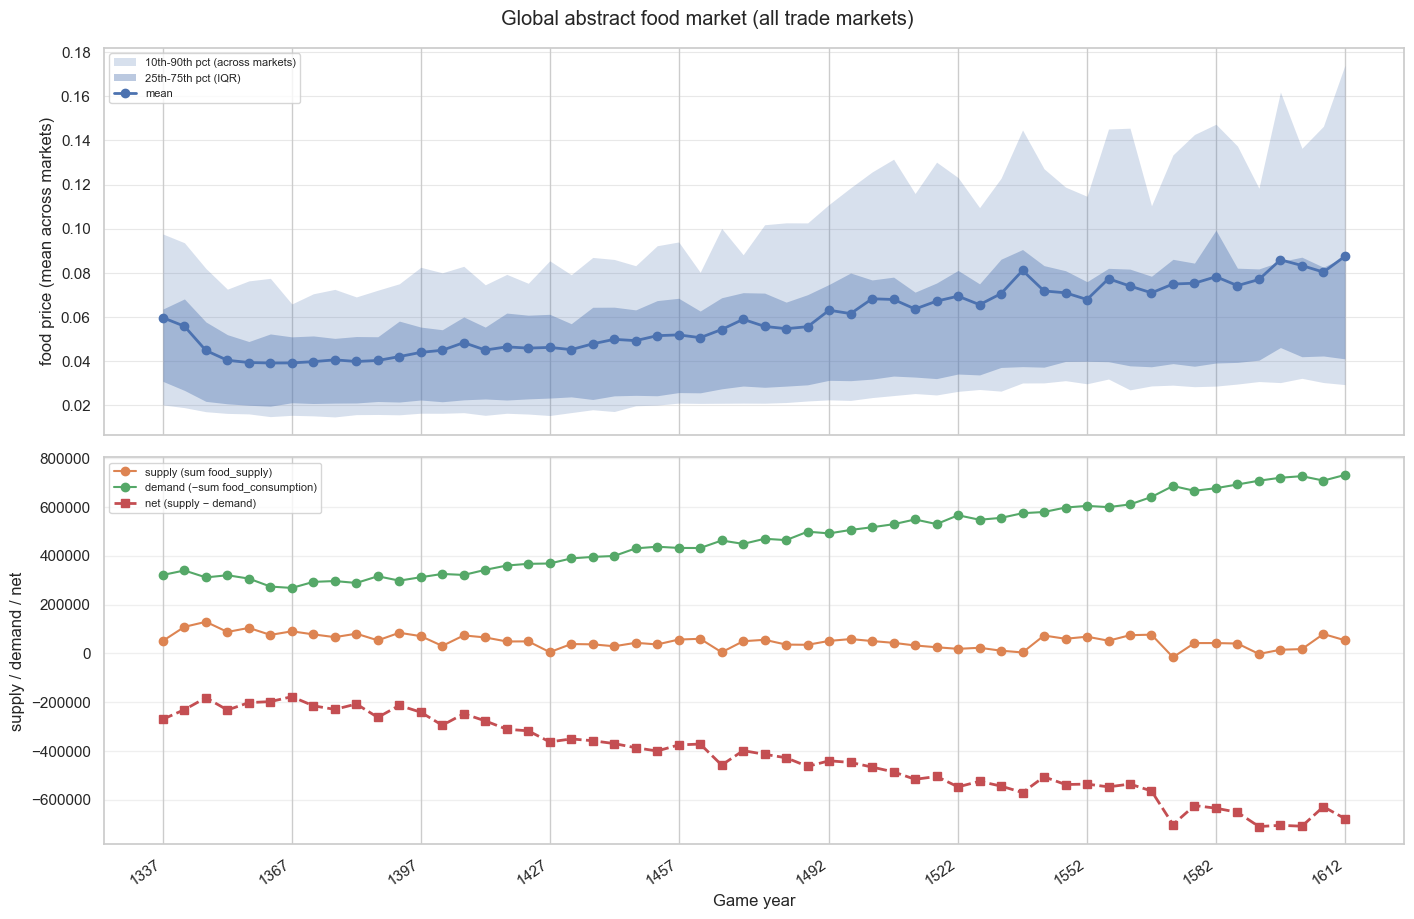

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Same timeline / tick density as compare_savegames_market (global good plot)
start_year_global = 1337
years_per_snapshot_global = 5
n_game_ticks = 10

sub = select_market_food_core(market_food_all)
if sub.empty or "snapshot" not in sub.columns:
    print("No market_food data for global plot.")
else:
    agg_dict: dict = {}
    if "price" in sub.columns:
        agg_dict["avg_price"] = ("price", "mean")
    if "food_supply" in sub.columns:
        agg_dict["global_supply"] = ("food_supply", "sum")
    if "food_consumption" in sub.columns:
        agg_dict["sum_consumption"] = ("food_consumption", "sum")

    if not agg_dict:
        print("Need at least one of: price, food_supply, food_consumption")
    else:
        global_food = sub.groupby("snapshot", as_index=False).agg(**agg_dict)
        global_food = global_food.sort_values("snapshot").reset_index(drop=True)

        if "sum_consumption" in global_food.columns:
            global_food["global_demand"] = -global_food["sum_consumption"]
            global_food = global_food.drop(columns=["sum_consumption"])

        if "global_supply" in global_food.columns and "global_demand" in global_food.columns:
            global_food["net_supply_minus_demand"] = (
                global_food["global_supply"] - global_food["global_demand"]
            )

        _snaps = global_food["snapshot"].tolist()
        price_band = None
        if "price" in sub.columns:
            price_band = (
                sub.groupby("snapshot")["price"]
                .agg(
                    p10=lambda s: s.quantile(0.1),
                    p25=lambda s: s.quantile(0.25),
                    p75=lambda s: s.quantile(0.75),
                    p90=lambda s: s.quantile(0.9),
                )
                .reindex(_snaps)
            )

        panels: list[str] = []
        if "avg_price" in global_food.columns:
            panels.append("price")
        if "global_supply" in global_food.columns and "global_demand" in global_food.columns:
            panels.append("supply_demand_net")
        elif "global_supply" in global_food.columns:
            panels.append("supply")
        elif "global_demand" in global_food.columns:
            panels.append("demand")

        if not panels:
            print("Nothing to plot.")
        else:
            n = len(panels)
            fig, axes = plt.subplots(
                n, 1, figsize=(13 * 1.1, 3.12 * 1.5 * n), sharex=True
            )
            if n == 1:
                axes = [axes]
            x = np.arange(len(global_food))
            for ax, panel in zip(axes, panels):
                if panel == "price":
                    color = "C0"
                    if price_band is not None:
                        ax.fill_between(
                            x,
                            price_band["p10"],
                            price_band["p90"],
                            alpha=0.22,
                            color=color,
                            linewidth=0,
                            label="10th-90th pct (across markets)",
                        )
                        ax.fill_between(
                            x,
                            price_band["p25"],
                            price_band["p75"],
                            alpha=0.38,
                            color=color,
                            linewidth=0,
                            label="25th-75th pct (IQR)",
                        )
                        ax.plot(
                            x,
                            global_food["avg_price"],
                            marker="o",
                            color=color,
                            linewidth=2,
                            zorder=3,
                            label="mean",
                        )
                        ax.legend(loc="best", fontsize=8)
                    else:
                        ax.plot(x, global_food["avg_price"], marker="o", color=color)
                    ax.set_ylabel("food price (mean across markets)")
                    ax.set_axisbelow(True)
                    ax.grid(
                        True,
                        axis="y",
                        which="major",
                        alpha=0.45,
                        linestyle="-",
                        linewidth=0.8,
                        zorder=0,
                    )
                elif panel == "supply_demand_net":
                    ax.plot(
                        x,
                        global_food["global_supply"],
                        marker="o",
                        color="C1",
                        label="supply (sum food_supply)",
                    )
                    ax.plot(
                        x,
                        global_food["global_demand"],
                        marker="o",
                        color="C2",
                        label="demand (−sum food_consumption)",
                    )
                    ax.plot(
                        x,
                        global_food["net_supply_minus_demand"],
                        marker="s",
                        color="C3",
                        linestyle="--",
                        linewidth=2,
                        label="net (supply − demand)",
                    )
                    ax.legend(loc="best", fontsize=8)
                    ax.set_ylabel("supply / demand / net")
                    ax.grid(True, axis="y", alpha=0.3)
                elif panel == "supply":
                    ax.plot(x, global_food["global_supply"], marker="o", color="C1")
                    ax.set_ylabel("global supply (sum)")
                    ax.grid(True, axis="y", alpha=0.3)
                elif panel == "demand":
                    ax.plot(x, global_food["global_demand"], marker="o", color="C2")
                    ax.set_ylabel("global demand")
                    ax.grid(True, axis="y", alpha=0.3)

            n_pts = len(x)
            if n_pts <= 1:
                tick_positions = list(range(n_pts))
            elif n_pts <= n_game_ticks:
                tick_positions = list(range(n_pts))
            else:
                step = (n_pts - 1) / (n_game_ticks - 1)
                tick_positions = [int(round(i * step)) for i in range(n_game_ticks)]
            tick_labels = [
                start_year_global + pos * years_per_snapshot_global
                for pos in tick_positions
            ]
            axes[-1].set_xticks(tick_positions)
            axes[-1].set_xticklabels(tick_labels, rotation=35, ha="right")
            axes[-1].set_xlabel("Game year")
            fig.suptitle("Global abstract food market (all trade markets)")
            plt.tight_layout()
            plt.show()


## Global stockpile vs global max (sum over markets)

**Global stockpile** = sum of abstract `food` per snapshot. **Global max** = sum of `food_max` per snapshot. The shaded band spans the two series (headroom when stockpile is below max).

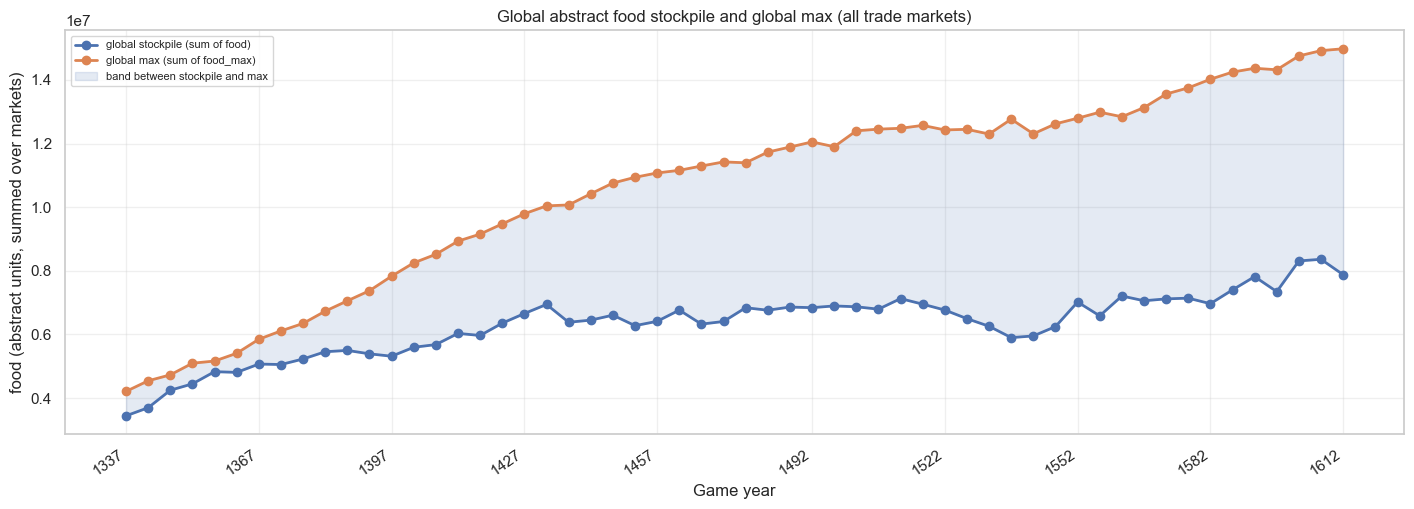

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Same game-year axis as other global plots
start_year_sp = 1337
years_per_snapshot_sp = 5
n_game_ticks = 10

sub = select_market_food_core(market_food_all)
if sub.empty or not {"food", "food_max"}.issubset(sub.columns):
    print("Need food and food_max for global stockpile plot.")
else:
    g = (
        sub.groupby("snapshot", as_index=False)
        .agg(
            global_stockpile=("food", "sum"),
            global_stockpile_max=("food_max", "sum"),
        )
        .sort_values("snapshot")
        .reset_index(drop=True)
    )
    x = np.arange(len(g))
    fig, ax = plt.subplots(figsize=(13 * 1.1, 3.5 * 1.5))
    ax.plot(
        x,
        g["global_stockpile"],
        marker="o",
        color="C0",
        linewidth=2,
        label="global stockpile (sum of food)",
    )
    ax.plot(
        x,
        g["global_stockpile_max"],
        marker="o",
        color="C1",
        linewidth=2,
        label="global max (sum of food_max)",
    )
    lo = g[["global_stockpile", "global_stockpile_max"]].min(axis=1)
    hi = g[["global_stockpile", "global_stockpile_max"]].max(axis=1)
    ax.fill_between(x, lo, hi, alpha=0.15, color="C0", label="band between stockpile and max")
    ax.legend(loc="best", fontsize=8)
    ax.set_ylabel("food (abstract units, summed over markets)")
    if len(x) <= 1:
        tick_positions = list(range(len(x)))
    elif len(x) <= n_game_ticks:
        tick_positions = list(range(len(x)))
    else:
        step = (len(x) - 1) / (n_game_ticks - 1)
        tick_positions = [int(round(i * step)) for i in range(n_game_ticks)]
    tick_labels = [start_year_sp + pos * years_per_snapshot_sp for pos in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=35, ha="right")
    ax.set_xlabel("Game year")
    ax.set_title("Global abstract food stockpile and global max (all trade markets)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Optional: parse directly from a `.eu5` save

Uncomment and set `RAW_SAVE_PATH` to verify `get_market_food_df` matches a pkl built from the same save.

In [20]:
# RAW_SAVE_PATH = r"C:\path\to\autosave_....eu5"
# from analysis.savegame.loader import get_market_food_df, load_save, select_market_food_core
#
# save = load_save(path=RAW_SAVE_PATH)
# df_raw = get_market_food_df(save)
# display(select_market_food_core(df_raw).head())